In [1]:
from IPython import get_ipython
import time

ip = get_ipython()
try:
    for cb in list(ip.events.callbacks['pre_run_cell']):
        ip.events.unregister('pre_run_cell', cb)
    for cb in list(ip.events.callbacks['post_run_cell']):
        ip.events.unregister('post_run_cell', cb)
    print("Callbacks limpiados")
except:
    print("Nada que limpiar")

try:
    from plyer import notification
    class ExecutionTimer:
        def __init__(self, threshold=60):
            self.start_time = None
            self.threshold  = threshold
        def pre_run(self, info):
            self.start_time = time.time()
        def post_run(self, result):
            if self.start_time:
                duration = time.time() - self.start_time
                if duration > self.threshold:
                    notification.notify(
                        title="¡Celda Finalizada!",
                        message=f"La ejecución tomó {duration:.2f}s.",
                        app_name="Jupyter", timeout=10
                    )
                self.start_time = None
    timer = ExecutionTimer(threshold=60)
    ip.events.register('pre_run_cell',  timer.pre_run)
    ip.events.register('post_run_cell', timer.post_run)
    print("Notificador configurado para celdas > 60s")
except ImportError:
    print("plyer no disponible — sin notificaciones")


Callbacks limpiados
Notificador configurado para celdas > 60s


In [2]:
import random, json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.sparse import csr_matrix
from numba import njit

# ── Rutas ─────────────────────────────────────────────────────────────────
TRAIN_PATH   = 'train.csv'
TEST_PATH    = 'test.csv'
GRID_LOG     = 'grid_search_log.csv'   # historial de todos los runs
BEST_CFG_PATH = 'best_cfg.json'        # mejor config + n_epochs_opt
MODEL_PATH   = 'pmf_final.npz'         # pesos del modelo final

RATING_MIN = 1.0
RATING_MAX = 10.0
SEED       = 42

random.seed(SEED)
np.random.seed(SEED)
print("Imports OK")


Imports OK


In [3]:
df_ratings = pd.read_csv(TRAIN_PATH)[['user', 'item', 'rating']]
print(f'Train raw: {df_ratings.shape} | ratings [{df_ratings.rating.min()}, {df_ratings.rating.max()}]')

# ── Encoders ──────────────────────────────────────────────────────────────
user2idx = {u: i for i, u in enumerate(sorted(df_ratings['user'].unique()))}
item2idx = {it: i for i, it in enumerate(sorted(df_ratings['item'].unique()))}

df = df_ratings.copy()
df['user'] = df['user'].map(user2idx)
df['item'] = df['item'].map(item2idx)

N_USERS = len(user2idx)
N_ITEMS = len(item2idx)

# ── Split random 80/20 ────────────────────────────────────────────────────
np.random.seed(SEED)
idx_all = np.random.permutation(len(df))
n_val   = int(len(df) * 0.20)
val_df   = df.iloc[idx_all[:n_val]].reset_index(drop=True)
train_df = df.iloc[idx_all[n_val:]].reset_index(drop=True)

# ── Split cold-start (val = usuarios distintos a train) ───────────────────
np.random.seed(SEED)
all_users   = df['user'].unique()
val_users   = set(np.random.choice(all_users, size=int(len(all_users) * 0.20), replace=False))
val_df_cold   = df[df['user'].isin(val_users)].reset_index(drop=True)
train_df_cold = df[~df['user'].isin(val_users)].reset_index(drop=True)

# ── Test competición ──────────────────────────────────────────────────────
df_test_comp = pd.read_csv(TEST_PATH)
df_test_comp['user'] = df_test_comp['user'].map(user2idx).fillna(-1).astype(int)
df_test_comp['item'] = df_test_comp['item'].map(item2idx).fillna(-1).astype(int)

# ── Matriz sparse (por si hace falta) ────────────────────────────────────
R_sparse = csr_matrix(
    (train_df['rating'].values, (train_df['user'].values, train_df['item'].values)),
    shape=(N_USERS, N_ITEMS)
)

print(f'Train: {len(train_df):,} | Val: {len(val_df):,}')
print(f'Train cold: {len(train_df_cold):,} | Val cold: {len(val_df_cold):,}')
print(f'N_USERS={N_USERS} | N_ITEMS={N_ITEMS}')
print(f'Test competición: {len(df_test_comp):,} pares')

cold_u = (df_test_comp['user'] == -1).sum()
cold_i = (df_test_comp['item'] == -1).sum()
print(f'  ⚠ Cold-start test: {cold_u} usuarios, {cold_i} items')


Train raw: (390351, 3) | ratings [1.0, 10.0]
Train: 312,281 | Val: 78,070
Train cold: 313,620 | Val cold: 76,731
N_USERS=73456 | N_ITEMS=171171
Test competición: 43,320 pares
  ⚠ Cold-start test: 4765 usuarios, 16157 items


In [4]:
ratings_per_user = df_ratings.groupby('user').size()
ratings_per_item = df_ratings.groupby('item').size()
mu_global        = df_ratings['rating'].mean()
n_users          = df_ratings['user'].nunique()
n_items          = df_ratings['item'].nunique()
n_ratings        = len(df_ratings)
sparsity         = 1 - n_ratings / (n_users * n_items)
cold_items       = (ratings_per_item < 5).sum()
cold_users       = (ratings_per_user < 5).sum()

stats = pd.DataFrame({
    'Métrica': ['Usuarios', 'Items', 'Ratings', 'Sparsidad',
                'Rating medio', 'Desv. típica',
                'Mediana ratings/usuario', 'Items cold-start (<5)',
                'Usuarios cold-start (<5)'],
    'Valor':   [f'{n_users:,}', f'{n_items:,}', f'{n_ratings:,}',
                f'{sparsity*100:.2f}%', f'{mu_global:.3f}',
                f'{df_ratings["rating"].std():.3f}',
                f'{ratings_per_user.median():.0f}',
                f'{cold_items} ({cold_items/n_items*100:.1f}%)',
                f'{cold_users} ({cold_users/n_users*100:.1f}%)']
})
display(stats.set_index('Métrica'))

# Análisis cold-start en test
both_known   = ((df_test_comp['user'] != -1) & (df_test_comp['item'] != -1)).sum()
item_cold    = ((df_test_comp['user'] != -1) & (df_test_comp['item'] == -1)).sum()
user_cold    = ((df_test_comp['user'] == -1) & (df_test_comp['item'] != -1)).sum()
double_cold  = ((df_test_comp['user'] == -1) & (df_test_comp['item'] == -1)).sum()
total_test   = len(df_test_comp)

print(f'\n--- Test cold-start breakdown ---')
print(f'Ambos conocidos:      {both_known:,} ({both_known/total_test*100:.1f}%)')
print(f'Solo item cold-start: {item_cold:,} ({item_cold/total_test*100:.1f}%)')
print(f'Solo user cold-start: {user_cold:,} ({user_cold/total_test*100:.1f}%)')
print(f'Doble cold-start:     {double_cold:,} ({double_cold/total_test*100:.1f}%)')


,Valor
Métrica,
Usuarios,"73,456"
Items,"171,171"
Ratings,"390,351"
Sparsidad,100.00%
Rating medio,7.605
Desv. típica,1.843
Mediana ratings/usuario,1
Items cold-start (<5),158169 (92.4%)
Usuarios cold-start (<5),60298 (82.1%)



--- Test cold-start breakdown ---
Ambos conocidos:      23,938 (55.3%)
Solo item cold-start: 14,617 (33.7%)
Solo user cold-start: 3,225 (7.4%)
Doble cold-start:     1,540 (3.6%)


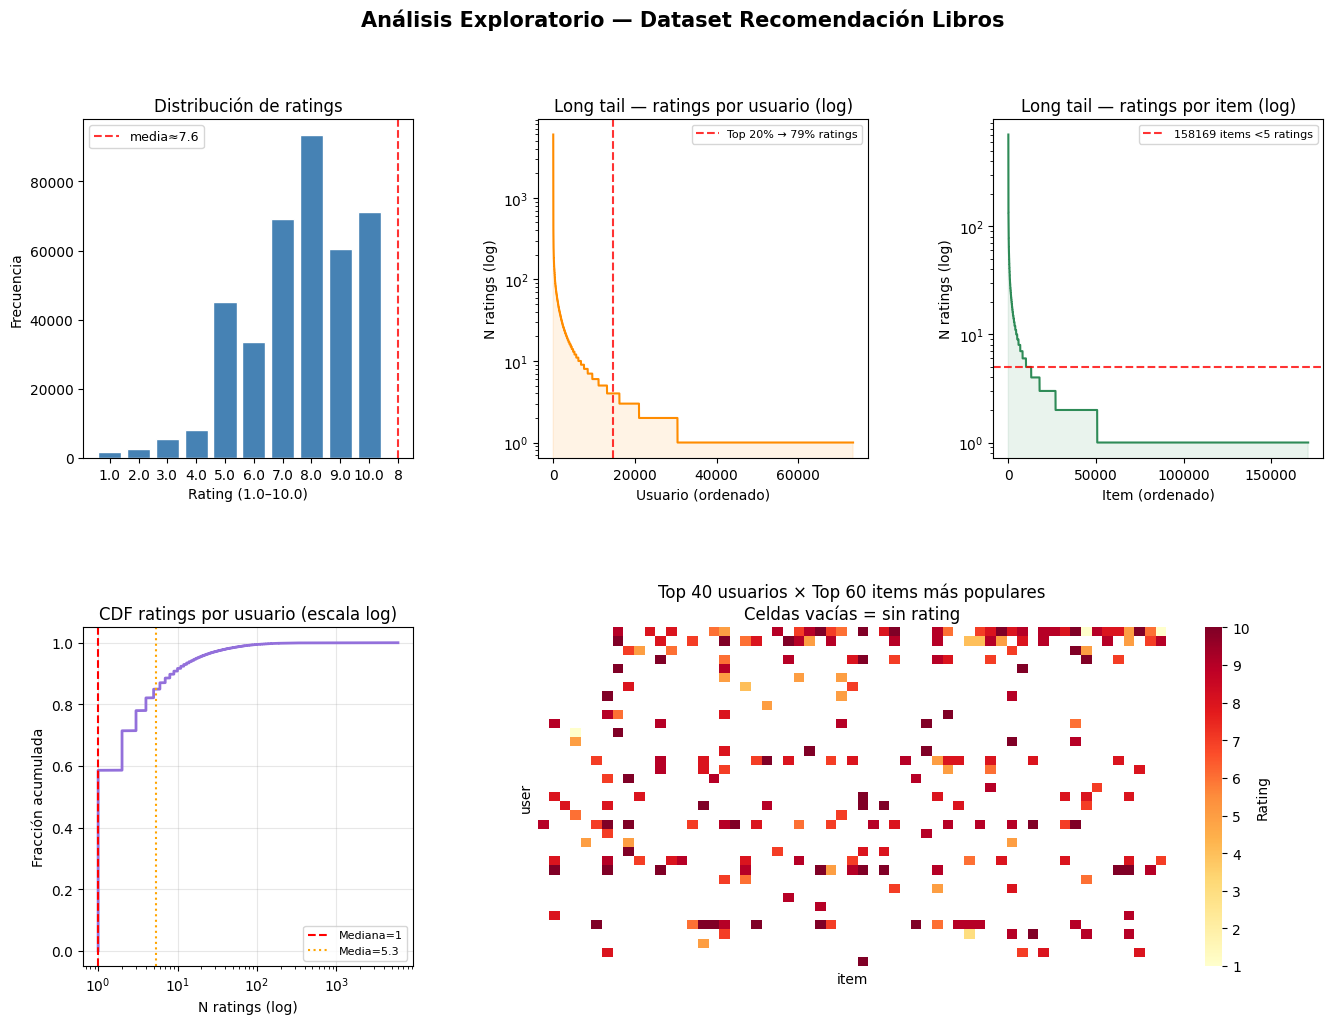

In [5]:
fig = plt.figure(figsize=(16, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.38)

ax1 = fig.add_subplot(gs[0, 0])
counts = df_ratings['rating'].value_counts().sort_index()
ax1.bar(counts.index.astype(str), counts.values, color='steelblue', edgecolor='white')
ax1.axvline(str(round(mu_global)), color='red', linestyle='--', alpha=0.8,
            label=f'media≈{mu_global:.1f}')
ax1.set_title('Distribución de ratings')
ax1.set_xlabel(f'Rating ({RATING_MIN}–{RATING_MAX})'); ax1.set_ylabel('Frecuencia')
ax1.legend(fontsize=9)

ax2 = fig.add_subplot(gs[0, 1])
su  = ratings_per_user.sort_values(ascending=False).values
ax2.semilogy(su, color='darkorange', linewidth=1.5)
ax2.fill_between(range(len(su)), su, alpha=0.1, color='darkorange')
p20 = int(len(su) * 0.2)
ax2.axvline(p20, color='red', linestyle='--', alpha=0.8,
            label=f'Top 20% → {su[:p20].sum()/n_ratings*100:.0f}% ratings')
ax2.set_title('Long tail — ratings por usuario (log)')
ax2.set_xlabel('Usuario (ordenado)'); ax2.set_ylabel('N ratings (log)')
ax2.legend(fontsize=8)

ax3 = fig.add_subplot(gs[0, 2])
si  = ratings_per_item.sort_values(ascending=False).values
ax3.semilogy(si, color='seagreen', linewidth=1.5)
ax3.fill_between(range(len(si)), si, alpha=0.1, color='seagreen')
ax3.axhline(5, color='red', linestyle='--', alpha=0.8, label=f'{cold_items} items <5 ratings')
ax3.set_title('Long tail — ratings por item (log)')
ax3.set_xlabel('Item (ordenado)'); ax3.set_ylabel('N ratings (log)')
ax3.legend(fontsize=8)

ax4 = fig.add_subplot(gs[1, 0])
sorted_u = np.sort(ratings_per_user.values)
cdf = np.arange(1, len(sorted_u)+1) / len(sorted_u)
ax4.plot(sorted_u, cdf, color='mediumpurple', linewidth=2)
ax4.axvline(ratings_per_user.median(), color='red', linestyle='--',
            label=f'Mediana={ratings_per_user.median():.0f}')
ax4.axvline(ratings_per_user.mean(), color='orange', linestyle=':',
            label=f'Media={ratings_per_user.mean():.1f}')
ax4.set_xscale('log')
ax4.set_title('CDF ratings por usuario (escala log)')
ax4.set_xlabel('N ratings (log)'); ax4.set_ylabel('Fracción acumulada')
ax4.legend(fontsize=8); ax4.grid(alpha=0.3)

ax5 = fig.add_subplot(gs[1, 1:])
top_u  = ratings_per_user.nlargest(40).index
pop_i  = ratings_per_item.nlargest(60).index
pivot  = df_ratings[
    df_ratings['user'].isin(top_u) & df_ratings['item'].isin(pop_i)
].pivot_table(index='user', columns='item', values='rating')
sns.heatmap(pivot, ax=ax5, cmap='YlOrRd', vmin=RATING_MIN, vmax=RATING_MAX,
            cbar_kws={'label': 'Rating'}, xticklabels=False, yticklabels=False,
            linewidths=0)
ax5.set_title('Top 40 usuarios × Top 60 items más populares\nCeldas vacías = sin rating')

fig.suptitle('Análisis Exploratorio — Dataset Recomendación Libros',
             fontsize=15, fontweight='bold')
plt.savefig('eda.png', bbox_inches='tight'); plt.show()


In [6]:
def mae(y_true, y_pred):
    return np.mean(np.abs(np.array(y_true) - np.array(y_pred)))

def evaluar(nombre, predict_fn, eval_df, verbose=True):
    y_true, y_pred = [], []
    for row in eval_df.itertuples():
        pred = float(np.clip(predict_fn(row.user, row.item), RATING_MIN, RATING_MAX))
        y_true.append(row.rating)
        y_pred.append(pred)
    score = mae(y_true, y_pred)
    if verbose:
        print(f'  {nombre:<15}  MAE = {score:.4f}')
    return {'modelo': nombre, 'MAE': score}

# ── Baselines ──────────────────────────────────────────────────────────────
mu_global_train  = train_df['rating'].mean()
item_means_train = train_df.groupby('item')['rating'].mean()
user_means_train = train_df.groupby('user')['rating'].mean()

evaluar('MediaGlobal',  lambda u, i: mu_global_train,                     val_df)
evaluar('MediaItem',    lambda u, i: item_means_train.get(i, mu_global_train), val_df)
evaluar('MediaUsuario', lambda u, i: user_means_train.get(u, mu_global_train), val_df)


  MediaGlobal      MAE = 1.4966
  MediaItem        MAE = 1.5369
  MediaUsuario     MAE = 1.2881


{'modelo': 'MediaUsuario', 'MAE': 1.2881257236653785}

---
## Comparativa de algoritmos
Ejecutar **en orden**. Todos usan el mismo `train_df` / `val_df` para comparación justa.

| # | Algoritmo | Librería |
|---|-----------|----------|
| 1 | Media global / por ítem / por usuario | — |
| 2 | KNN (user-based y item-based) | surprise |
| 3 | PMF (Simon Funk SVD con bias) | numba (custom) |
| 4 | NMF | sklearn |
| 5 | BNMF (Bayesian NMF) | nimfa / sklearn |

Al final se muestra un ranking comparativo.


In [7]:
# ══════════════════════════════════════════════════════════════════════════
# 1. BASELINES DE MEDIA
# ══════════════════════════════════════════════════════════════════════════
resultados = []

mu_global_train  = train_df['rating'].mean()
item_means_train = train_df.groupby('item')['rating'].mean()
user_means_train = train_df.groupby('user')['rating'].mean()

# Media global
res = evaluar('MediaGlobal', lambda u, i: mu_global_train, val_df)
resultados.append(res)

# Media por ítem
res = evaluar('MediaItem', lambda u, i: item_means_train.get(i, mu_global_train), val_df)
resultados.append(res)

# Media por usuario
res = evaluar('MediaUsuario', lambda u, i: user_means_train.get(u, mu_global_train), val_df)
resultados.append(res)

# Media shrinkada (Bayesian) — mejor fallback que media pura
K_SHRINK = 10
item_stats   = train_df.groupby('item')['rating'].agg(['mean', 'count'])
item_shrunk  = {
    item: (row['count'] * row['mean'] + K_SHRINK * mu_global_train) / (row['count'] + K_SHRINK)
    for item, row in item_stats.iterrows()
}
user_stats   = train_df.groupby('user')['rating'].agg(['mean', 'count'])
user_shrunk  = {
    user: (row['count'] * row['mean'] + K_SHRINK * mu_global_train) / (row['count'] + K_SHRINK)
    for user, row in user_stats.iterrows()
}

def predict_shrunk(u, i):
    if u not in user_shrunk and i not in item_shrunk:
        return mu_global_train
    if u not in user_shrunk:
        return item_shrunk.get(i, mu_global_train)
    if i not in item_shrunk:
        return user_shrunk.get(u, mu_global_train)
    # ambos conocidos: media de las dos medias shrinkadas
    return (user_shrunk[u] + item_shrunk[i]) / 2.0

res = evaluar(f'MediaShrunk(k={K_SHRINK})', predict_shrunk, val_df)
resultados.append(res)


  MediaGlobal      MAE = 1.4966
  MediaItem        MAE = 1.5369
  MediaUsuario     MAE = 1.2881
  MediaShrunk(k=10)  MAE = 1.3178


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# 2. KNN  (Surprise — KNNWithMeans user-based e item-based)
# Nota: con mediana=1 rating/usuario el KNN sufre mucho — esperamos MAE alto
# ══════════════════════════════════════════════════════════════════════════
from surprise import KNNWithMeans, Dataset, Reader
from surprise import accuracy as surp_acc

reader     = Reader(rating_scale=(RATING_MIN, RATING_MAX))
train_data = Dataset.load_from_df(train_df[['user', 'item', 'rating']], reader)
trainset   = train_data.build_full_trainset()
testset    = [(row.user, row.item, row.rating) for row in val_df.itertuples()]

# ── User-based ────────────────────────────────────────────────────────────
print('Entrenando KNN user-based...')
knn_user = KNNWithMeans(
    k=40,
    min_k=2,
    sim_options={'name': 'pearson_baseline', 'user_based': True},
    verbose=False
)
knn_user.fit(trainset)
preds_knn_user = knn_user.test(testset)
mae_knn_user   = surp_acc.mae(preds_knn_user, verbose=False)
print(f'  KNN_user     MAE = {mae_knn_user:.4f}')
resultados.append({'modelo': 'KNN_user', 'MAE': mae_knn_user})

# ── Item-based ────────────────────────────────────────────────────────────
print('Entrenando KNN item-based...')
knn_item = KNNWithMeans(
    k=40,
    min_k=2,
    sim_options={'name': 'pearson_baseline', 'user_based': False},
    verbose=False
)
knn_item.fit(trainset)
preds_knn_item = knn_item.test(testset)
mae_knn_item   = surp_acc.mae(preds_knn_item, verbose=False)
print(f'  KNN_item     MAE = {mae_knn_item:.4f}')
resultados.append({'modelo': 'KNN_item', 'MAE': mae_knn_item})


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# 3. PMF  (custom Numba — config base, no el tuneado)
# Para la comparativa usamos parámetros razonables sin grid search completo
# ══════════════════════════════════════════════════════════════════════════
random.seed(SEED); np.random.seed(SEED)

pmf_base = PMF(
    n_factors = 200,
    n_epochs  = 100,
    lr        = 0.01,
    reg       = 0.02,
    reg_bias  = 0.001,
    patience  = 5,
    shrink_k  = 10
)
pmf_base.fit(train_df, val_df)
mae_pmf = min(pmf_base.val_mae)
print(f'  PMF_base     MAE = {mae_pmf:.4f}  (época {len(pmf_base.val_mae)})')
resultados.append({'modelo': 'PMF_base', 'MAE': mae_pmf})

# Mejor config conocida (si ya tienes best_cfg.json del grid search)
if os.path.exists(BEST_CFG_PATH):
    with open(BEST_CFG_PATH) as f:
        ckpt = json.load(f)
    print(f'  [Referencia] PMF_tuned → {ckpt.get("val_mae", "?")} '
          f'(config: n_factors={ckpt["n_factors"]}, lr={ckpt["lr"]}, '
          f'reg={ckpt["reg"]}, rb={ckpt["reg_bias"]})')


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# 4. NMF  (sklearn — factorización no negativa sobre la matriz sparse)
# Limitaciones: no hay bias, cold-start puro → fallback a media global
# ══════════════════════════════════════════════════════════════════════════
from sklearn.decomposition import NMF as SklearnNMF
from scipy.sparse import csr_matrix as csr

print('Entrenando NMF (sklearn)...')

# ── Construir matriz sparse de train ──────────────────────────────────────
R_train_sp = csr(
    (train_df['rating'].values,
     (train_df['user'].values, train_df['item'].values)),
    shape=(N_USERS, N_ITEMS),
    dtype=np.float32
)

NMF_FACTORS = 200
nmf_model = SklearnNMF(
    n_components  = NMF_FACTORS,
    init          = 'nndsvda',      # inicialización determinista, mejor convergencia
    max_iter      = 300,
    random_state  = SEED,
    l1_ratio      = 0.0,
    alpha_W       = 0.01,
    alpha_H       = 'same',
    verbose       = 0
)

W = nmf_model.fit_transform(R_train_sp)   # (N_USERS, k)
H = nmf_model.components_                 # (k, N_ITEMS)

# ── Media global para cold-start ──────────────────────────────────────────
mu_nmf = train_df['rating'].mean()

def predict_nmf(user, item):
    if user < 0 or user >= N_USERS or item < 0 or item >= N_ITEMS:
        return mu_nmf
    return float(np.clip(W[user] @ H[:, item], RATING_MIN, RATING_MAX))

res = evaluar('NMF', predict_nmf, val_df)
resultados.append(res)
print(f'  NMF_sklearn  MAE = {res["MAE"]:.4f}')


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# 5. BNMF  (Bayesian NMF — nimfa si disponible, fallback a NMF regularizado)
#
# nimfa implementa Bayesian NMF con priors de Poisson/Gaussiano.
# Si no está instalado, usamos NMF de sklearn con regularización fuerte
# como aproximación práctica (L1+L2 shrinkage ≈ prior bayesiano débil).
# ══════════════════════════════════════════════════════════════════════════
try:
    import nimfa
    NIMFA_OK = True
except ImportError:
    NIMFA_OK = False
    print('nimfa no instalado — usando NMF regularizado como proxy BNMF')
    print('Para instalar: pip install nimfa')

if NIMFA_OK:
    # ── BNMF con nimfa (Bayesian Gaussian NMF) ────────────────────────────
    print('Entrenando BNMF (nimfa)...')
    R_dense = R_train_sp.toarray().astype(np.float64)

    bnmf = nimfa.Bmf(
        R_dense,
        rank      = 50,          # menor rango que NMF — más regularizado
        max_iter  = 100,
        lambda_w  = 1.2,         # prior en W
        lambda_h  = 1.2,         # prior en H
    )
    bnmf_fit = bnmf()
    W_b = np.array(bnmf_fit.basis())
    H_b = np.array(bnmf_fit.coef())

    def predict_bnmf(user, item):
        if user < 0 or user >= N_USERS or item < 0 or item >= N_ITEMS:
            return mu_nmf
        return float(np.clip(W_b[user] @ H_b[:, item], RATING_MIN, RATING_MAX))

    res = evaluar('BNMF_nimfa', predict_bnmf, val_df)
    resultados.append(res)

else:
    # ── Proxy: NMF fuertemente regularizado (L1+L2) ───────────────────────
    print('Entrenando BNMF-proxy (NMF L1+L2 regularizado)...')
    bnmf_proxy = SklearnNMF(
        n_components  = 100,
        init          = 'nndsvda',
        max_iter      = 300,
        random_state  = SEED,
        l1_ratio      = 0.5,     # mezcla L1+L2 — prior laplaciano/gaussiano
        alpha_W       = 0.1,
        alpha_H       = 'same',
        verbose       = 0
    )
    W_b = bnmf_proxy.fit_transform(R_train_sp)
    H_b = bnmf_proxy.components_

    def predict_bnmf(user, item):
        if user < 0 or user >= N_USERS or item < 0 or item >= N_ITEMS:
            return mu_nmf
        return float(np.clip(W_b[user] @ H_b[:, item], RATING_MIN, RATING_MAX))

    res = evaluar('BNMF_proxy', predict_bnmf, val_df)
    resultados.append(res)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# RANKING COMPARATIVO
# ══════════════════════════════════════════════════════════════════════════
df_res = pd.DataFrame(resultados).sort_values('MAE').reset_index(drop=True)
df_res.index += 1
df_res['Δ vs mejor'] = (df_res['MAE'] - df_res['MAE'].iloc[0]).round(4)

print('\n' + '═'*45)
print('  RANKING FINAL — VAL MAE (lower is better)')
print('═'*45)
display(df_res)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(df_res))]
bars = ax.barh(df_res['modelo'][::-1], df_res['MAE'][::-1], color=colors[::-1], edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.set_xlabel('MAE (val)')
ax.set_title('Comparativa de algoritmos — Recomendación de Libros')
ax.axvline(df_res['MAE'].iloc[0], color='green', linestyle='--', alpha=0.5, label='Mejor')
ax.legend()
plt.tight_layout()
plt.savefig('comparativa_algoritmos.png', bbox_inches='tight')
plt.show()


In [ ]:
@njit
def _sgd_epoch(users, items, ratings, U, V, bu, bi, mu, lr, reg, reg_bias):
    idx = np.random.permutation(len(users))
    total_err = 0.0
    for i in idx:
        u, v, r = users[i], items[i], ratings[i]
        pred = mu + bu[u] + bi[v] + np.dot(U[u], V[v])
        err  = r - pred
        total_err += abs(err)
        bu[u] += lr * (err - reg_bias * bu[u])
        bi[v] += lr * (err - reg_bias * bi[v])
        U[u]  += lr * (err * V[v] - reg * U[u])
        V[v]  += lr * (err * U[u] - reg * V[v])
    return total_err / len(users)


class PMF:
    """
    PMF con bias (Simon Funk SVD, Koren 2008).
    SGD compilado con Numba + Bayesian shrinkage en cold-start.

    Parámetros
    ----------
    shrink_k : int
        Factor de shrinkage para fallback cold-start.
        k=0 → media pura. k alto → tira hacia mu global.
        Rango recomendado: 5–50.
    """

    def __init__(self, n_factors=50, n_epochs=100, lr=0.005,
                 reg=0.02, reg_bias=0.005, patience=5, shrink_k=10):
        self.n_factors = n_factors
        self.n_epochs  = n_epochs
        self.lr        = lr
        self.reg       = reg
        self.reg_bias  = reg_bias
        self.patience  = patience
        self.shrink_k  = shrink_k
        self.train_mae = []
        self.val_mae   = []

    # ── Entrenamiento ──────────────────────────────────────────────────────
    def fit(self, train_df, val_df=None, seed=SEED):
        np.random.seed(seed)

        full_df = train_df if val_df is None else pd.concat([train_df, val_df])
        n_u = full_df['user'].max() + 1
        n_i = full_df['item'].max() + 1

        self.U  = np.random.normal(0, 0.01, (n_u, self.n_factors))
        self.V  = np.random.normal(0, 0.01, (n_i, self.n_factors))
        self.bu = np.zeros(n_u)
        self.bi = np.zeros(n_i)
        self.mu = train_df['rating'].mean()

        # Fallback con Bayesian shrinkage
        k = self.shrink_k
        item_stats = train_df.groupby('item')['rating'].agg(['mean', 'count'])
        self.item_mean = {
            item: (row['count'] * row['mean'] + k * self.mu) / (row['count'] + k)
            for item, row in item_stats.iterrows()
        }
        user_stats = train_df.groupby('user')['rating'].agg(['mean', 'count'])
        self.user_mean = {
            user: (row['count'] * row['mean'] + k * self.mu) / (row['count'] + k)
            for user, row in user_stats.iterrows()
        }

        users   = train_df['user'].values.astype(np.int64)
        items   = train_df['item'].values.astype(np.int64)
        ratings = train_df['rating'].values.astype(np.float64)

        best_val          = float('inf')
        epochs_no_improve = 0
        best_state        = None

        print('  Compilando Numba (solo primera vez)...')
        for epoch in range(self.n_epochs):
            t_mae = _sgd_epoch(
                users, items, ratings,
                self.U, self.V, self.bu, self.bi, self.mu,
                self.lr, self.reg, self.reg_bias
            )
            self.train_mae.append(t_mae)

            if val_df is not None:
                v_mae = evaluar('', self.predict, val_df, verbose=False)['MAE']
                self.val_mae.append(v_mae)

                if v_mae < best_val:
                    best_val          = v_mae
                    epochs_no_improve = 0
                    best_state = {k: getattr(self, k).copy() for k in ['U', 'V', 'bu', 'bi']}
                else:
                    epochs_no_improve += 1
                    if epochs_no_improve >= self.patience:
                        print(f'  Early stopping en época {epoch+1} | mejor val MAE: {best_val:.4f}')
                        for k, v in best_state.items():
                            setattr(self, k, v)
                        break

            if (epoch + 1) % 10 == 0:
                msg = f'  Epoch {epoch+1:>3}/{self.n_epochs} | train: {self.train_mae[-1]:.4f}'
                if val_df is not None:
                    msg += f' | val: {self.val_mae[-1]:.4f}'
                print(msg)
        return self

    # ── Predicción ────────────────────────────────────────────────────────
    def predict(self, user, item):
        u_known = 0 <= user < self.U.shape[0]
        i_known = 0 <= item < self.V.shape[0]

        if not u_known and not i_known:
            return self.mu
        if not u_known:
            return self.item_mean.get(item, self.mu)
        if not i_known:
            return self.user_mean.get(user, self.mu)
        return self.mu + self.bu[user] + self.bi[item] + self.U[user] @ self.V[item]

    # ── Persistencia ──────────────────────────────────────────────────────
    def save(self, path=MODEL_PATH):
        """Guarda pesos en disco para no reentrenar."""
        np.savez_compressed(
            path,
            U=self.U, V=self.V, bu=self.bu, bi=self.bi,
            mu=np.array([self.mu]),
            shrink_k=np.array([self.shrink_k]),
            train_mae=np.array(self.train_mae),
            val_mae=np.array(self.val_mae),
            user_mean_keys=np.array(list(self.user_mean.keys())),
            user_mean_vals=np.array(list(self.user_mean.values())),
            item_mean_keys=np.array(list(self.item_mean.keys())),
            item_mean_vals=np.array(list(self.item_mean.values())),
        )
        print(f'  Modelo guardado → {path}')

    @classmethod
    def load(cls, path=MODEL_PATH):
        """Carga modelo desde disco. No necesita reentrenar."""
        data = np.load(path, allow_pickle=False)
        m = cls.__new__(cls)
        m.U         = data['U']
        m.V         = data['V']
        m.bu        = data['bu']
        m.bi        = data['bi']
        m.mu        = float(data['mu'][0])
        m.shrink_k  = int(data['shrink_k'][0])
        m.train_mae = list(data['train_mae'])
        m.val_mae   = list(data['val_mae'])
        m.user_mean = dict(zip(data['user_mean_keys'].tolist(),
                               data['user_mean_vals'].tolist()))
        m.item_mean = dict(zip(data['item_mean_keys'].tolist(),
                               data['item_mean_vals'].tolist()))
        m.n_factors = m.U.shape[1]
        print(f'  Modelo cargado ← {path}  (U={m.U.shape}, shrink_k={m.shrink_k})')
        return m

print("Clase PMF definida OK")


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# GRID SEARCH — edita configs y ejecuta.
# Los resultados se ACUMULAN en GRID_LOG para no perder histórico.
# Al final guarda automáticamente best_cfg.json.
# ══════════════════════════════════════════════════════════════════════════

configs = [
    {'n_factors': f, 'lr': lr, 'reg': reg, 'reg_bias': rb, 'shrink_k': k}
    for f   in [800]
    for lr  in [0.016]
    for reg in [0.10]
    for rb  in [0.001]
    for k   in [5, 10, 20, 50]          # ← ajusta aquí
]
print(f'Total configuraciones: {len(configs)}')

# ── Cargar log anterior si existe ─────────────────────────────────────────
if os.path.exists(GRID_LOG):
    df_log = pd.read_csv(GRID_LOG)
    print(f'Log existente: {len(df_log)} runs previos cargados')
else:
    df_log = pd.DataFrame()

# ── Loop ──────────────────────────────────────────────────────────────────
best_mae, best_cfg, best_pmf = float('inf'), None, None

for cfg in configs:
    random.seed(SEED); np.random.seed(SEED)
    m = PMF(
        n_factors = cfg['n_factors'],
        n_epochs  = 100,
        lr        = cfg['lr'],
        reg       = cfg['reg'],
        reg_bias  = cfg['reg_bias'],
        patience  = 5,
        shrink_k  = cfg.get('shrink_k', 10)
    )
    m.fit(train_df_cold, val_df_cold)
    val_mae    = min(m.val_mae)
    n_epochs   = len(m.val_mae)

    row = {**cfg, 'val_mae': val_mae, 'n_epochs': n_epochs}
    df_log = pd.concat([df_log, pd.DataFrame([row])], ignore_index=True)
    df_log.to_csv(GRID_LOG, index=False)   # guardar después de CADA run

    print(f"f={cfg['n_factors']:>4} lr={cfg['lr']} reg={cfg['reg']} "
          f"rb={cfg['reg_bias']} k={cfg.get('shrink_k',10):>2} "
          f"ep={n_epochs:>3} → val MAE: {val_mae:.4f}")

    if val_mae < best_mae:
        best_mae = val_mae
        best_cfg = cfg
        best_pmf = m

print(f'\nMejor esta sesión: {best_cfg} → {best_mae:.4f}')
print(f'Épocas óptimas:    {len(best_pmf.val_mae)}')

# ── Guardar mejor config en disco ─────────────────────────────────────────
checkpoint = {
    **best_cfg,
    'val_mae':    best_mae,
    'n_epochs_opt': len(best_pmf.val_mae)
}
with open(BEST_CFG_PATH, 'w') as f:
    json.dump(checkpoint, f, indent=2)
print(f'Config guardada → {BEST_CFG_PATH}')

# ── Ver top 10 del historial completo ─────────────────────────────────────
print(f'\n─── Top 10 historial global ({GRID_LOG}) ───')
display(df_log.sort_values('val_mae').head(10))


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# REENTRENAR — carga config desde disco y entrena sobre train+val completo.
# Si el modelo ya está guardado, lo carga directamente sin reentrenar.
# ══════════════════════════════════════════════════════════════════════════

if os.path.exists(MODEL_PATH):
    print(f'Modelo encontrado en {MODEL_PATH} — cargando sin reentrenar...')
    pmf_final = PMF.load(MODEL_PATH)
else:
    # ── Cargar mejor config ────────────────────────────────────────────────
    with open(BEST_CFG_PATH) as f:
        checkpoint = json.load(f)

    best_cfg      = {k: v for k, v in checkpoint.items()
                     if k not in ('val_mae', 'n_epochs_opt')}
    n_epochs_opt  = checkpoint['n_epochs_opt']

    print(f'Config cargada: {best_cfg}')
    print(f'Épocas óptimas: {n_epochs_opt}')

    # ── Reentrenar con TODO el dataset ────────────────────────────────────
    full_train = pd.concat([train_df, val_df]).reset_index(drop=True)
    random.seed(SEED); np.random.seed(SEED)

    pmf_final = PMF(
        n_factors = best_cfg['n_factors'],
        n_epochs  = n_epochs_opt,
        lr        = best_cfg['lr'],
        reg       = best_cfg['reg'],
        reg_bias  = best_cfg['reg_bias'],
        patience  = 999,
        shrink_k  = best_cfg.get('shrink_k', 10)
    )
    pmf_final.fit(full_train)

    # ── Guardar modelo ────────────────────────────────────────────────────
    pmf_final.save(MODEL_PATH)

print('\nModelo listo para submission.')


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# SUBMISSION — genera el CSV de predicciones.
# Si quieres forzar reentrenamiento: borra MODEL_PATH y ejecuta celda 8.
# ══════════════════════════════════════════════════════════════════════════

preds = [
    round(float(np.clip(pmf_final.predict(row.user, row.item), RATING_MIN, RATING_MAX)), 4)
    for row in df_test_comp.itertuples()
]

submission = pd.DataFrame({'ID': df_test_comp['ID'], 'rating': preds})
submission.to_csv('submission_final.csv', index=False)
print(f'submission_final.csv generado: {len(submission):,} predicciones')
submission.head()


In [ ]:
# ══════════════════════════════════════════════════════════════════════════
# ANÁLISIS DE ERRORES — ejecutar sobre val_df para diagnosticar
# ══════════════════════════════════════════════════════════════════════════

errores = {'ambos_conocidos': [], 'item_cold': [], 'user_cold': [], 'doble_cold': []}
todas_preds, todos_reales = [], []

for row in val_df.itertuples():
    u, i, r = row.user, row.item, row.rating
    pred = float(np.clip(pmf_final.predict(u, i), RATING_MIN, RATING_MAX))
    err  = abs(r - pred)
    todas_preds.append(pred); todos_reales.append(r)

    u_known = 0 <= u < pmf_final.U.shape[0]
    i_known = 0 <= i < pmf_final.V.shape[0]

    if u_known and i_known:     errores['ambos_conocidos'].append(err)
    elif not u_known and i_known: errores['user_cold'].append(err)
    elif u_known and not i_known: errores['item_cold'].append(err)
    else:                         errores['doble_cold'].append(err)

print('Segmento               | N      |  MAE   | % val')
print('-'*50)
total = sum(len(v) for v in errores.values())
for seg, errs in errores.items():
    if errs:
        print(f'{seg:<22} | {len(errs):>6} | {np.mean(errs):.4f} | {len(errs)/total*100:.1f}%')

# ── Gráficas ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
todos_errores = [abs(r - p) for r, p in zip(todos_reales, todas_preds)]

axes[0].hist(todos_errores, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(todos_errores), color='red', linestyle='--',
                label=f'MAE={np.mean(todos_errores):.4f}')
axes[0].set_title('Distribución errores absolutos'); axes[0].legend()

axes[1].scatter(todos_reales, todas_preds, alpha=0.1, s=1, color='steelblue')
axes[1].plot([RATING_MIN, RATING_MAX], [RATING_MIN, RATING_MAX], 'r--', linewidth=2)
axes[1].set_title('Predicho vs Real')
axes[1].set_xlabel('Rating real'); axes[1].set_ylabel('Rating predicho')

df_err = pd.DataFrame({'real': todos_reales, 'error': todos_errores})
df_err.groupby('real')['error'].mean().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('MAE por rating real'); axes[2].set_xlabel('Rating real')

plt.tight_layout()
plt.savefig('error_analysis.png', bbox_inches='tight')
plt.show()
